# 📊 Analyzing Elon Musk's Crypto Tweet Impact

## Interpreting Crypto Token Dynamics with LLMs: A Data-Driven Exploration of Narratives and Price Movements

---

### Project Overview

This notebook analyzes the relationship between Elon Musk's Twitter activity and cryptocurrency price movements. Using LLM-extracted features from ~1,000 crypto-related tweets (2012-2025), we examine:

- **Sentiment Analysis**: How do positive/negative tweets correlate with price changes?
- **Event Classification**: Which types of tweets (endorsements, memes, market commentary) move prices?
- **Market Signals**: Do tweets with explicit buy/sell signals predict price direction?
- **Temporal Patterns**: When do Musk's crypto tweets have the most impact?

### Data Pipeline Summary

```
Raw Tweets (55K) → Crypto Filter (1K) → LLM Feature Extraction → Price Data Alignment → Analysis
```

---

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings

warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Color palettes
SENTIMENT_COLORS = {'positive': '#2ecc71', 'neutral': '#95a5a6', 'negative': '#e74c3c'}
TOKEN_COLORS = {'DOGE': '#c2a633', 'BTC': '#f7931a', 'ETH': '#627eea', 'SHIB': '#fda32b', 'Other': '#95a5a6'}

In [2]:
# Load data
df = pd.read_csv('../data/curated/musk_crypto_tweets_final.csv')

# Parse dates
df['createdAt'] = pd.to_datetime(df['createdAt'])

# Exclude rows with missing price data (edge cases: pre-DOGE era, BABYDOGE)
df_clean = df[df['price_at_tweet'].notna()].copy()

print(f"Total tweets loaded: {len(df):,}")
print(f"Tweets with price data: {len(df_clean):,}")
print(f"Excluded (missing price): {len(df) - len(df_clean)}")
print(f"\nDate range: {df_clean['createdAt'].min().date()} to {df_clean['createdAt'].max().date()}")

Total tweets loaded: 1,003
Tweets with price data: 998
Excluded (missing price): 5

Date range: 2014-03-14 to 2025-04-13


In [3]:
# Quick overview
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 998 entries, 0 to 1002
Data columns (total 45 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   id                       998 non-null    int64              
 1   fullText                 998 non-null    object             
 2   retweetCount             998 non-null    float64            
 3   replyCount               997 non-null    float64            
 4   likeCount                998 non-null    float64            
 5   quoteCount               996 non-null    float64            
 6   viewCount                758 non-null    float64            
 7   createdAt                998 non-null    datetime64[ns, UTC]
 8   isReply                  998 non-null    bool               
 9   bookmarkCount            996 non-null    float64            
 10  inReplyToUsername        327 non-null    object             
 11  isRetweet                998 non-nul

---

## 2. Dataset Overview

### 2.1 Feature Summary

| Category | Features | Description |
|----------|----------|-------------|
| **Tweet Metadata** | `id`, `fullText`, `createdAt`, `tweet_type` | Original tweet data |
| **Engagement** | `likeCount`, `retweetCount`, `replyCount`, `viewCount` | Interaction metrics |
| **Derived Metrics** | `engagement_rate`, `virality_ratio`, `conversation_ratio` | Computed engagement features |
| **LLM-Extracted** | `sentiment`, `sentiment_score`, `event_type`, `crypto_tokens`, `market_signal` | AI-classified features |
| **Price Data** | `price_at_tweet`, `price_after_1h`, `price_after_24h`, `pct_change_*` | Crypto price alignment |

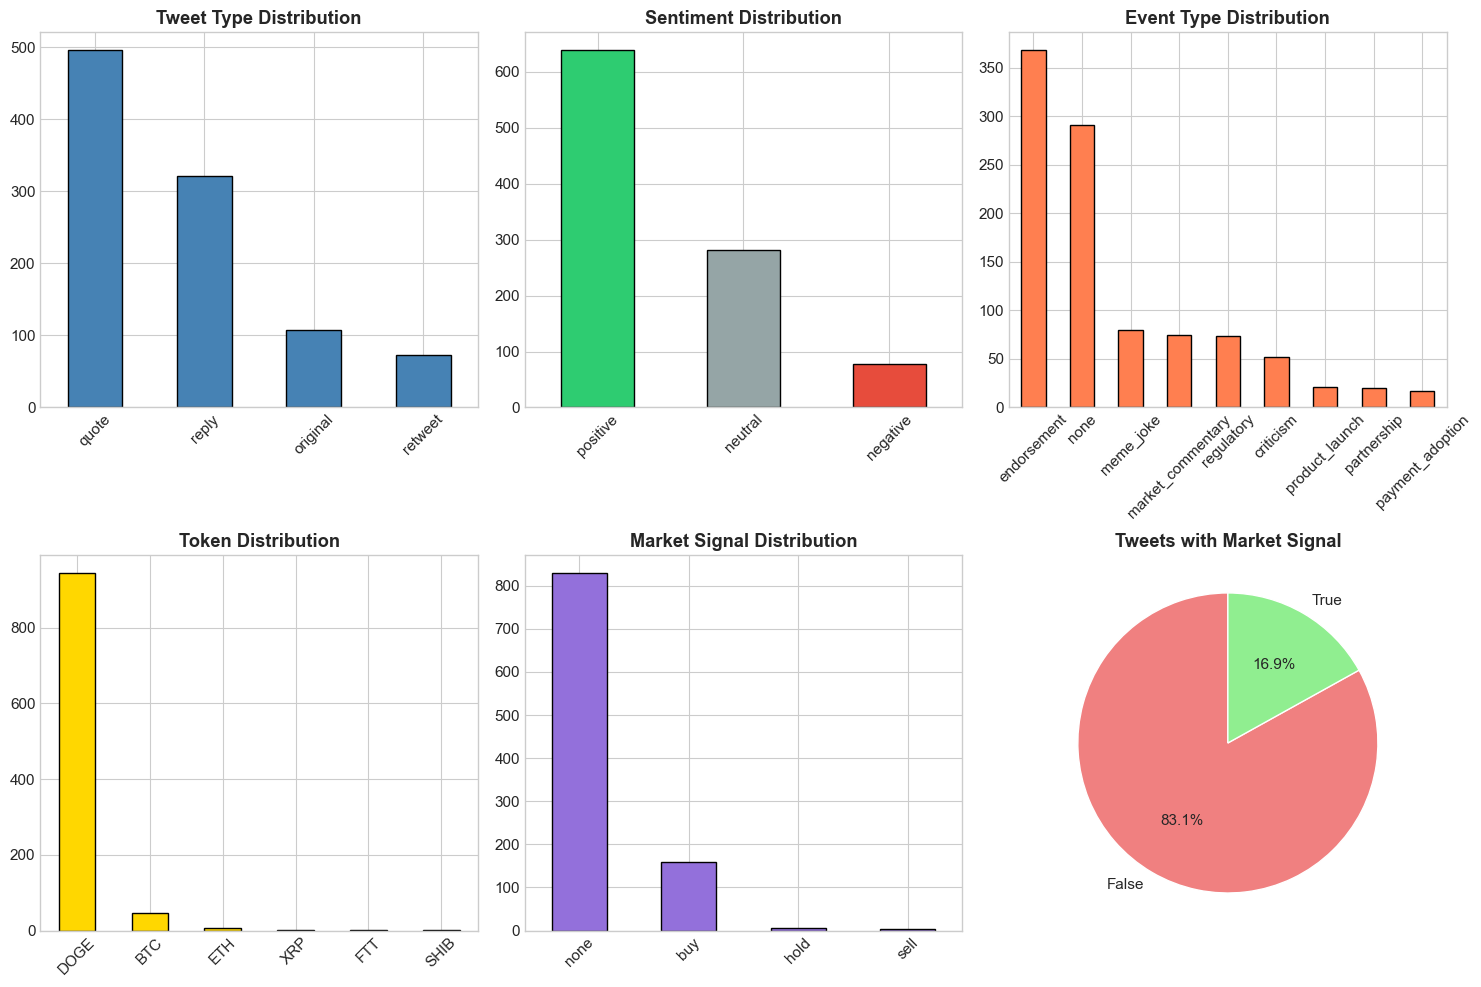

In [4]:
# Categorical distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Tweet type
df_clean['tweet_type'].value_counts().plot(kind='bar', ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Tweet Type Distribution', fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)

# Sentiment
sentiment_counts = df_clean['sentiment'].value_counts()
sentiment_counts.plot(kind='bar', ax=axes[0, 1], color=[SENTIMENT_COLORS[s] for s in sentiment_counts.index], edgecolor='black')
axes[0, 1].set_title('Sentiment Distribution', fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)

# Event type
df_clean['event_type'].value_counts().plot(kind='bar', ax=axes[0, 2], color='coral', edgecolor='black')
axes[0, 2].set_title('Event Type Distribution', fontweight='bold')
axes[0, 2].set_xlabel('')
axes[0, 2].tick_params(axis='x', rotation=45)

# Price token
df_clean['price_token'].value_counts().plot(kind='bar', ax=axes[1, 0], color='gold', edgecolor='black')
axes[1, 0].set_title('Token Distribution', fontweight='bold')
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', rotation=45)

# Market signal
df_clean['market_signal'].value_counts().plot(kind='bar', ax=axes[1, 1], color='mediumpurple', edgecolor='black')
axes[1, 1].set_title('Market Signal Distribution', fontweight='bold')
axes[1, 1].set_xlabel('')
axes[1, 1].tick_params(axis='x', rotation=45)

# Has market signal
df_clean['has_market_signal'].value_counts().plot(kind='pie', ax=axes[1, 2], autopct='%1.1f%%', 
                                                   colors=['lightcoral', 'lightgreen'], startangle=90)
axes[1, 2].set_title('Tweets with Market Signal', fontweight='bold')
axes[1, 2].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/01_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Key Observations

- **Tweet Types**: Quote tweets dominate (~50%), suggesting Musk often reacts to crypto content
- **Sentiment**: Overwhelmingly positive (64%), reflecting Musk's generally bullish crypto stance
- **Event Types**: Endorsements are most common (37%), followed by unclassified content
- **Tokens**: DOGE dominates (94%), confirming Musk's strong association with Dogecoin
- **Market Signals**: Only 17% of tweets contain explicit buy/sell signals

---

## 3. Temporal Analysis

### 3.1 Tweet Volume Over Time

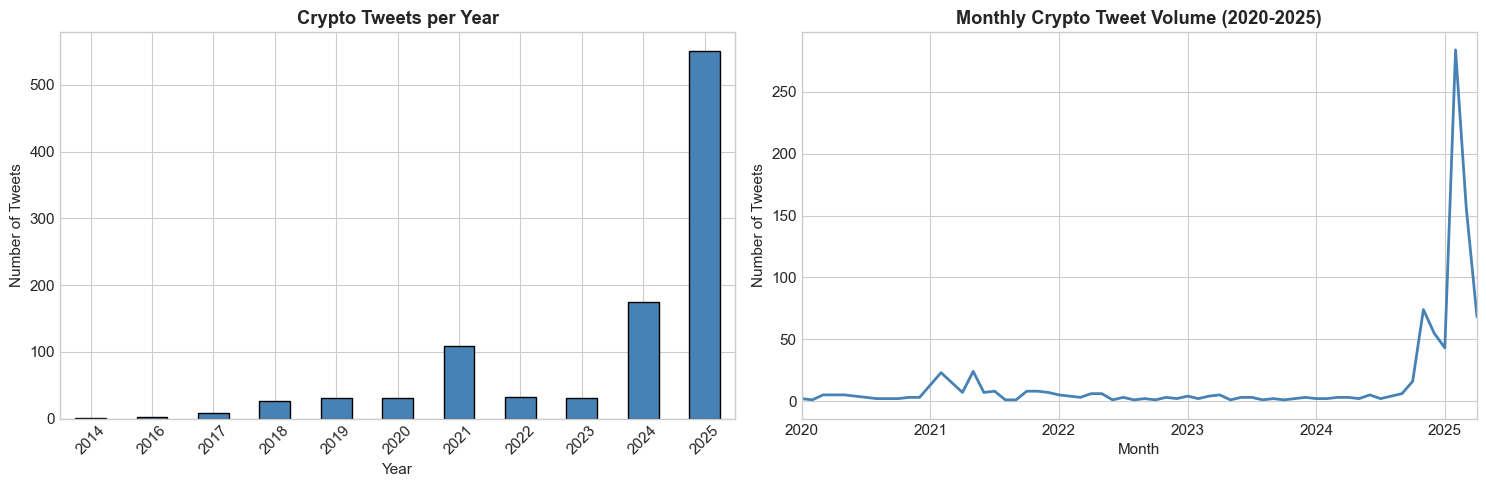

Peak year: 2025 (551 tweets)


In [5]:
# Tweets per year
df_clean['year'] = df_clean['createdAt'].dt.year
df_clean['month'] = df_clean['createdAt'].dt.to_period('M')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Yearly distribution
yearly = df_clean.groupby('year').size()
yearly.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Crypto Tweets per Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Tweets')
axes[0].tick_params(axis='x', rotation=45)

# Monthly trend (2020-2025 focus)
monthly = df_clean[df_clean['year'] >= 2020].groupby('month').size()
monthly.plot(ax=axes[1], color='steelblue', linewidth=2)
axes[1].set_title('Monthly Crypto Tweet Volume (2020-2025)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Tweets')
axes[1].fill_between(range(len(monthly)), monthly.values, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/figures/02_temporal_volume.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Peak year: {yearly.idxmax()} ({yearly.max()} tweets)")

### 3.2 Hourly & Daily Patterns

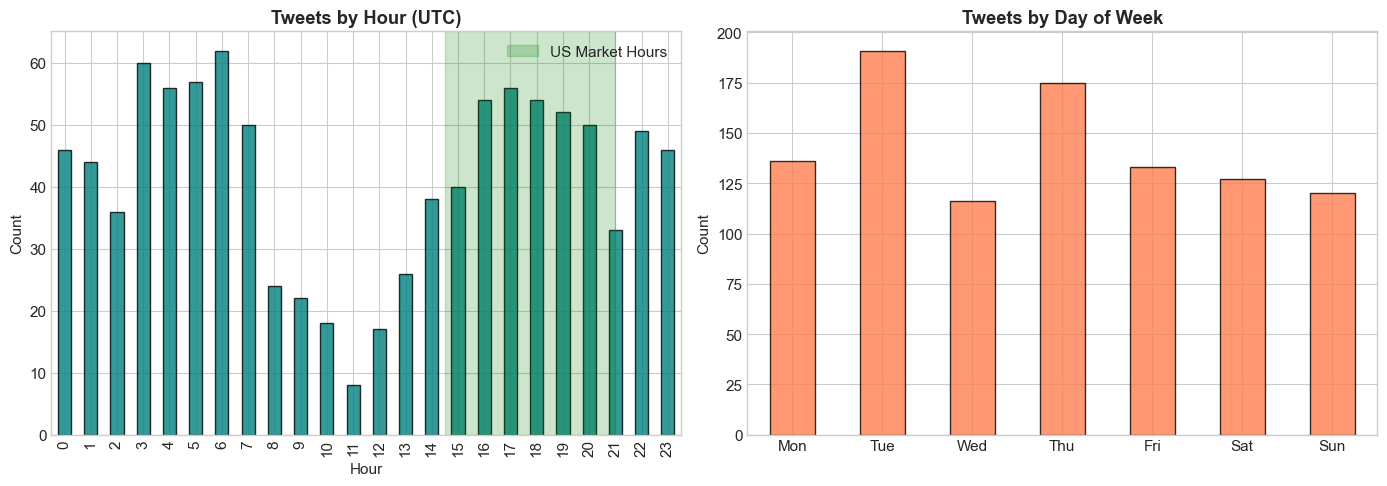

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hourly distribution
hourly = df_clean.groupby('hour_utc').size()
hourly.plot(kind='bar', ax=axes[0], color='teal', edgecolor='black', alpha=0.8)
axes[0].set_title('Tweets by Hour (UTC)', fontweight='bold')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')
axes[0].axvspan(14.5, 21, alpha=0.2, color='green', label='US Market Hours')
axes[0].legend()

# Day of week
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily = df_clean.groupby('day_of_week').size()
daily.index = [days[i] for i in daily.index]
daily.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black', alpha=0.8)
axes[1].set_title('Tweets by Day of Week', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/03_hourly_daily.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Market hours vs non-market hours analysis
market_hours_comparison = df_clean.groupby('is_us_market_hours')[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].agg(['mean', 'std', 'count'])
print("Price Change Comparison: US Market Hours vs Off-Hours")
print("="*60)
print(market_hours_comparison.round(3))

Price Change Comparison: US Market Hours vs Off-Hours
                   pct_change_1h              pct_change_24h               \
                            mean    std count           mean    std count   
is_us_market_hours                                                          
False                     -0.023  0.838   743         -0.563  7.322   743   
True                       0.000  0.000   255          0.241  4.417   255   

                   pct_change_7d                
                            mean     std count  
is_us_market_hours                              
False                     -2.482  15.707   743  
True                      -0.668  13.380   255  


---

## 4. Price Impact Analysis

This is the core analysis: **Do Musk's tweets move crypto prices?**

### 4.1 Overall Price Changes After Tweets

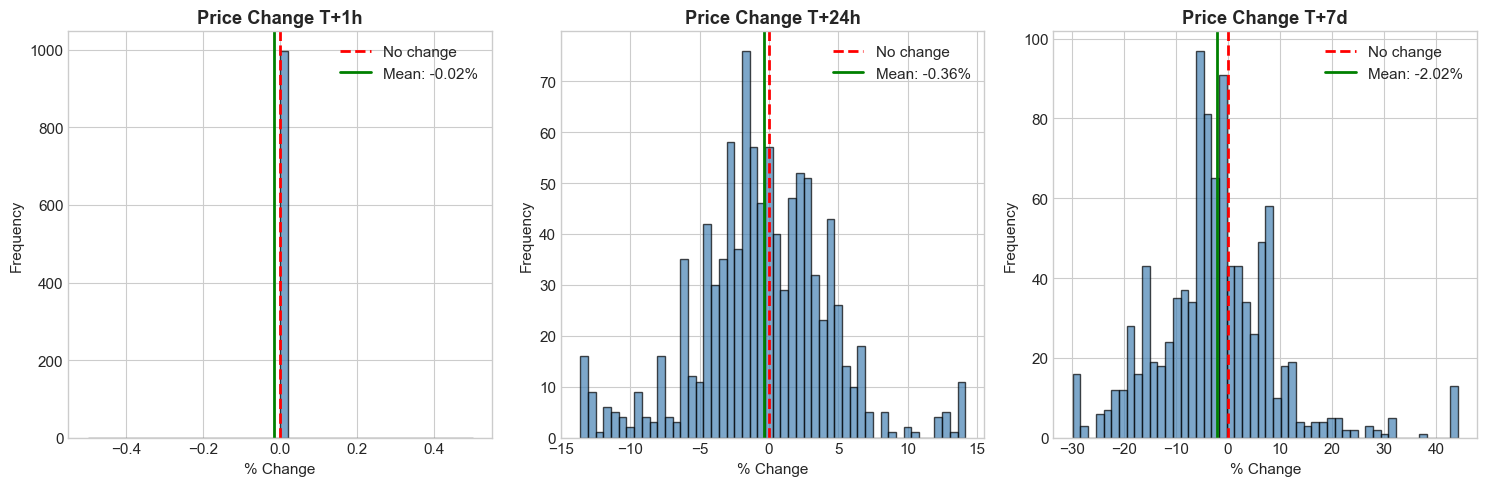


Price Change Summary Statistics:
       pct_change_1h  pct_change_24h  pct_change_7d
count        998.000         998.000        998.000
mean          -0.017          -0.358         -2.018
std            0.723           6.707         15.160
min          -16.876         -32.047        -49.518
25%            0.000          -3.043         -8.827
50%            0.000          -0.595         -2.933
75%            0.000           2.570          3.306
max            5.799         100.164        148.300


In [8]:
# Distribution of price changes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (col, title) in enumerate([
    ('pct_change_1h', 'Price Change T+1h'),
    ('pct_change_24h', 'Price Change T+24h'),
    ('pct_change_7d', 'Price Change T+7d')
]):
    data = df_clean[col].dropna()
    
    # Clip extreme outliers for visualization
    data_clipped = data.clip(lower=data.quantile(0.01), upper=data.quantile(0.99))
    
    axes[i].hist(data_clipped, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
    axes[i].axvline(x=data.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {data.mean():.2f}%')
    axes[i].set_title(title, fontweight='bold')
    axes[i].set_xlabel('% Change')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../reports/figures/04_price_change_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nPrice Change Summary Statistics:")
print("="*50)
print(df_clean[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].describe().round(3))

### 4.2 Price Impact by Sentiment

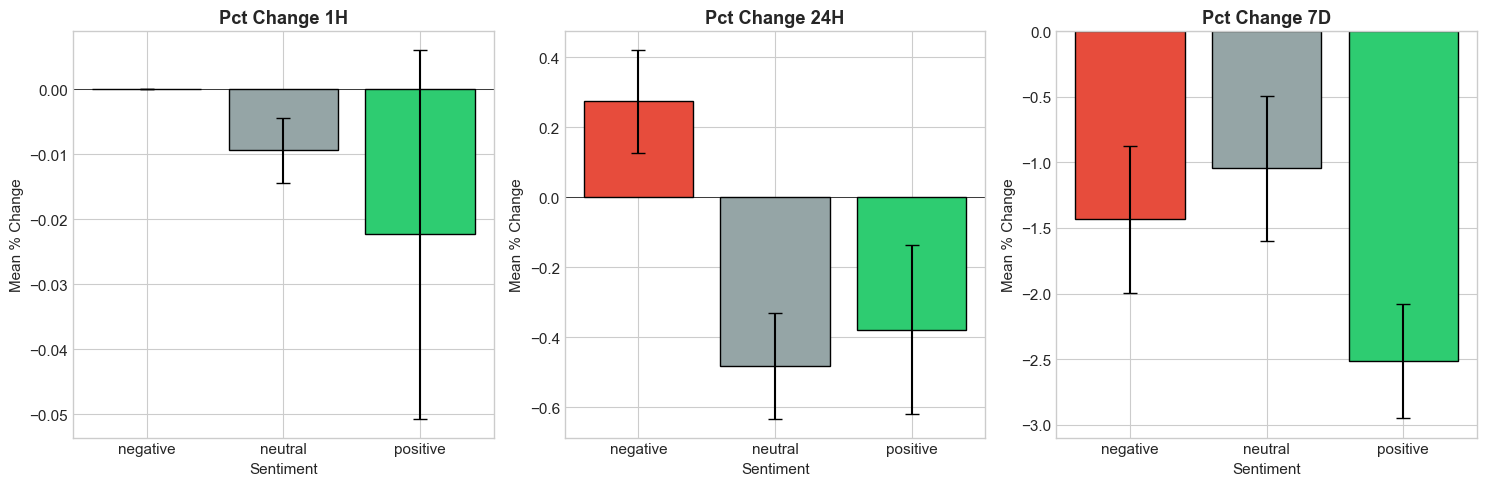


Price Impact by Sentiment:
          pct_change_1h              pct_change_24h               \
                   mean    std count           mean    std count   
sentiment                                                          
negative          0.000  0.000    77          0.274  4.638    77   
neutral          -0.009  0.159   282         -0.483  4.786   282   
positive         -0.022  0.898   639         -0.378  7.589   639   

          pct_change_7d                
                   mean     std count  
sentiment                              
negative         -1.435  17.672    77  
neutral          -1.046  17.396   282  
positive         -2.518  13.710   639  


In [9]:
# Group by sentiment
sentiment_impact = df_clean.groupby('sentiment')[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].agg(['mean', 'std', 'count'])

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(['pct_change_1h', 'pct_change_24h', 'pct_change_7d']):
    means = df_clean.groupby('sentiment')[col].mean()
    stds = df_clean.groupby('sentiment')[col].std()
    
    colors = [SENTIMENT_COLORS[s] for s in means.index]
    bars = axes[i].bar(means.index, means.values, yerr=stds.values/np.sqrt(len(df_clean)), 
                       color=colors, edgecolor='black', capsize=5)
    axes[i].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[i].set_title(f'{col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_ylabel('Mean % Change')
    axes[i].set_xlabel('Sentiment')

plt.tight_layout()
plt.savefig('../reports/figures/05_sentiment_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPrice Impact by Sentiment:")
print("="*60)
print(sentiment_impact.round(3))

### 4.3 Price Impact by Event Type

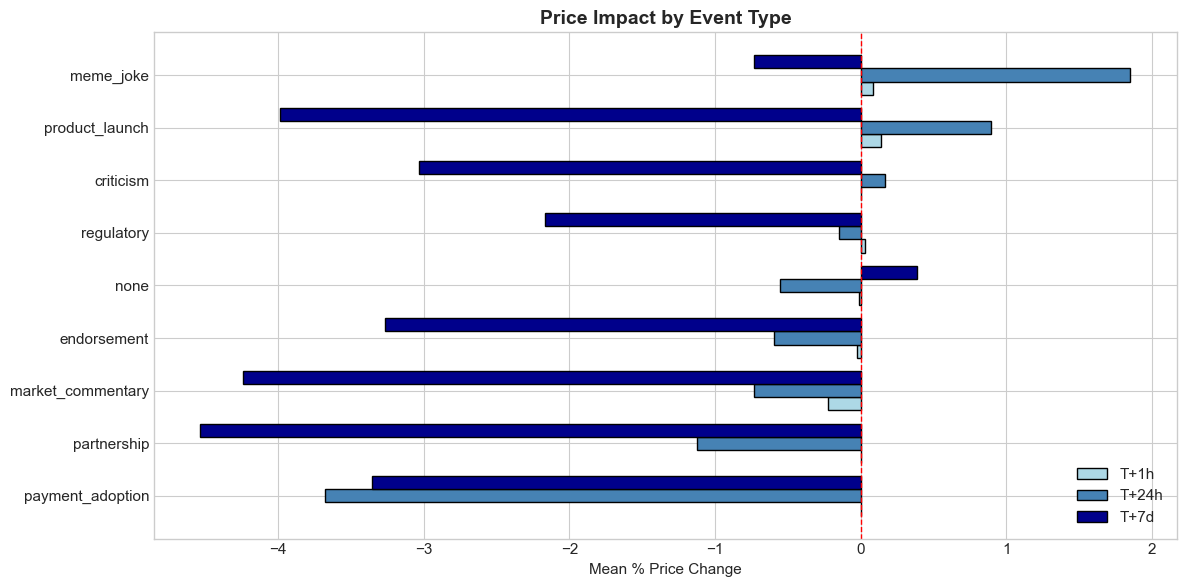


Price Impact by Event Type:
                   pct_change_1h  pct_change_24h  pct_change_7d
event_type                                                     
payment_adoption           0.000          -3.680         -3.356
partnership                0.000          -1.123         -4.532
market_commentary         -0.225          -0.733         -4.239
endorsement               -0.025          -0.597         -3.265
none                      -0.009          -0.555          0.388
regulatory                 0.030          -0.153         -2.166
criticism                  0.000           0.169         -3.029
product_launch             0.142           0.896         -3.990
meme_joke                  0.081           1.852         -0.732


In [10]:
# Group by event type
event_impact = df_clean.groupby('event_type')[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].mean()

# Sort by 24h impact
event_impact_sorted = event_impact.sort_values('pct_change_24h', ascending=True)

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(event_impact_sorted))
width = 0.25

bars1 = ax.barh(x - width, event_impact_sorted['pct_change_1h'], width, label='T+1h', color='lightblue', edgecolor='black')
bars2 = ax.barh(x, event_impact_sorted['pct_change_24h'], width, label='T+24h', color='steelblue', edgecolor='black')
bars3 = ax.barh(x + width, event_impact_sorted['pct_change_7d'], width, label='T+7d', color='darkblue', edgecolor='black')

ax.set_yticks(x)
ax.set_yticklabels(event_impact_sorted.index)
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Mean % Price Change')
ax.set_title('Price Impact by Event Type', fontweight='bold', fontsize=14)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../reports/figures/06_event_type_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPrice Impact by Event Type:")
print("="*60)
print(event_impact_sorted.round(3))

### 4.4 Market Signal Effectiveness

Do tweets with explicit market signals (buy/sell/hold) predict price direction?

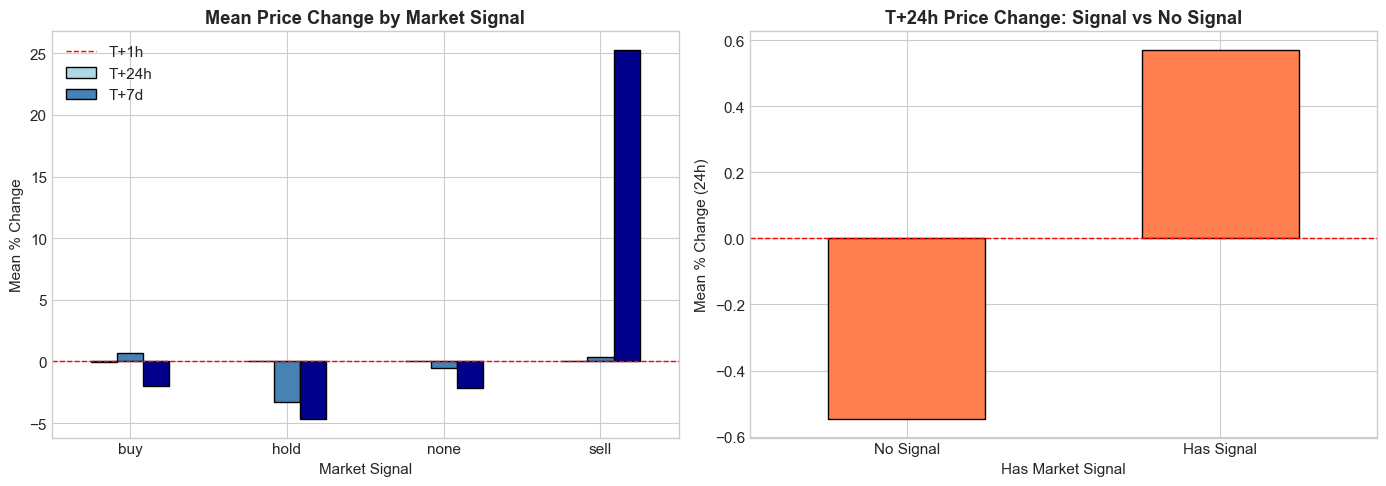


Market Signal Impact:
              pct_change_1h       pct_change_24h       pct_change_7d      
                       mean count           mean count          mean count
market_signal                                                             
buy                  -0.081   160          0.697   160        -1.981   160
hold                  0.000     5         -3.269     5        -4.684     5
none                 -0.005   829         -0.547   829        -2.141   829
sell                  0.000     4          0.330     4        25.288     4


In [11]:
# Market signal analysis
signal_impact = df_clean.groupby('market_signal')[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].agg(['mean', 'count'])

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of mean price changes
signal_means = df_clean.groupby('market_signal')[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].mean()
signal_means.plot(kind='bar', ax=axes[0], color=['lightblue', 'steelblue', 'darkblue'], edgecolor='black')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Mean Price Change by Market Signal', fontweight='bold')
axes[0].set_xlabel('Market Signal')
axes[0].set_ylabel('Mean % Change')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(['T+1h', 'T+24h', 'T+7d'])

# Has market signal comparison
has_signal = df_clean.groupby('has_market_signal')[['pct_change_24h']].mean()
has_signal.plot(kind='bar', ax=axes[1], color=['coral', 'lightgreen'], edgecolor='black', legend=False)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('T+24h Price Change: Signal vs No Signal', fontweight='bold')
axes[1].set_xlabel('Has Market Signal')
axes[1].set_ylabel('Mean % Change (24h)')
axes[1].set_xticklabels(['No Signal', 'Has Signal'], rotation=0)

plt.tight_layout()
plt.savefig('../reports/figures/07_market_signal.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMarket Signal Impact:")
print("="*60)
print(signal_impact.round(3))

---

## 5. Engagement Analysis

### 5.1 Engagement vs Price Impact

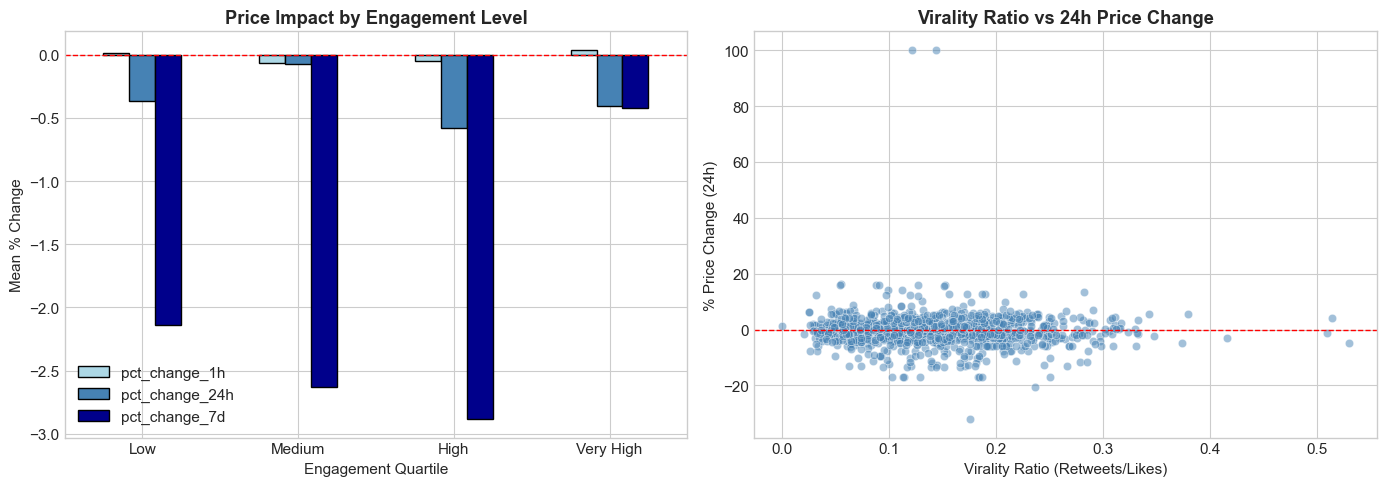

In [12]:
# Create engagement quartiles
df_clean['engagement_quartile'] = pd.qcut(df_clean['likeCount'].fillna(0), q=4, labels=['Low', 'Medium', 'High', 'Very High'])

engagement_impact = df_clean.groupby('engagement_quartile')[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].mean()

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Engagement quartile impact
engagement_impact.plot(kind='bar', ax=axes[0], color=['lightblue', 'steelblue', 'darkblue'], edgecolor='black')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0].set_title('Price Impact by Engagement Level', fontweight='bold')
axes[0].set_xlabel('Engagement Quartile')
axes[0].set_ylabel('Mean % Change')
axes[0].tick_params(axis='x', rotation=0)

# Scatter: virality vs price change
scatter_data = df_clean[df_clean['virality_ratio'].notna() & (df_clean['virality_ratio'] < 5)]
axes[1].scatter(scatter_data['virality_ratio'], scatter_data['pct_change_24h'], 
                alpha=0.5, c='steelblue', edgecolor='white', linewidth=0.5)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Virality Ratio vs 24h Price Change', fontweight='bold')
axes[1].set_xlabel('Virality Ratio (Retweets/Likes)')
axes[1].set_ylabel('% Price Change (24h)')

plt.tight_layout()
plt.savefig('../reports/figures/08_engagement_impact.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Token-Specific Analysis

### 6.1 DOGE vs Other Tokens

DOGE vs Other Tokens:

DOGE tweets: 944 (94.6%)
Other tokens: 54 (5.4%)

DOGE mean 24h change: -0.377%
Other mean 24h change: -0.020%


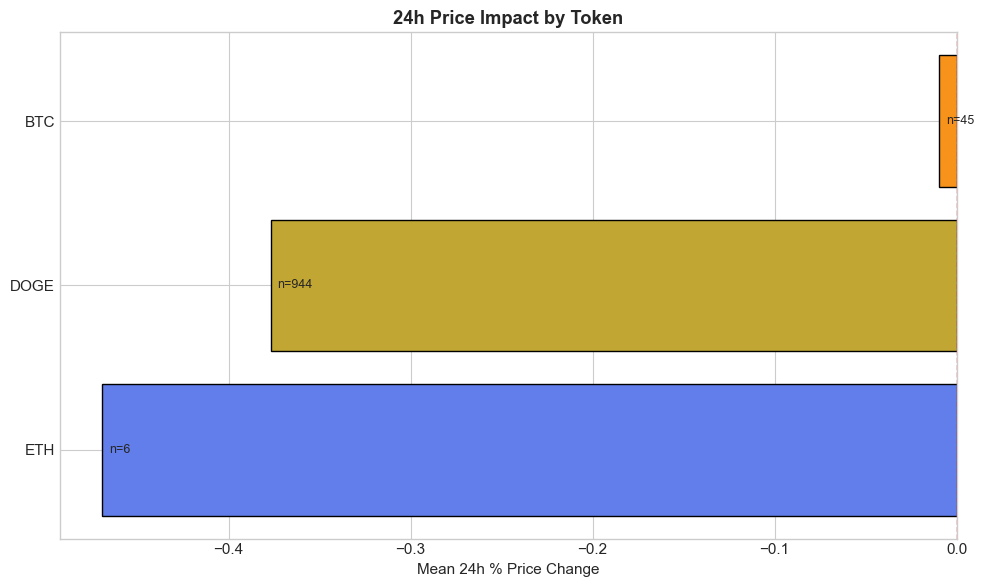

In [13]:
# Token comparison
token_impact = df_clean.groupby('price_token')[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].agg(['mean', 'std', 'count'])

# DOGE specific analysis
doge_data = df_clean[df_clean['price_token'] == 'DOGE']
other_data = df_clean[df_clean['price_token'] != 'DOGE']

print("DOGE vs Other Tokens:")
print("="*50)
print(f"\nDOGE tweets: {len(doge_data)} ({100*len(doge_data)/len(df_clean):.1f}%)")
print(f"Other tokens: {len(other_data)} ({100*len(other_data)/len(df_clean):.1f}%)")
print(f"\nDOGE mean 24h change: {doge_data['pct_change_24h'].mean():.3f}%")
print(f"Other mean 24h change: {other_data['pct_change_24h'].mean():.3f}%")

# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Filter to tokens with enough data
token_counts = df_clean['price_token'].value_counts()
major_tokens = token_counts[token_counts >= 5].index.tolist()

token_means = df_clean[df_clean['price_token'].isin(major_tokens)].groupby('price_token')['pct_change_24h'].mean().sort_values()

colors = [TOKEN_COLORS.get(t, TOKEN_COLORS['Other']) for t in token_means.index]
bars = ax.barh(token_means.index, token_means.values, color=colors, edgecolor='black')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Mean 24h % Price Change')
ax.set_title('24h Price Impact by Token', fontweight='bold')

# Add count annotations
for i, (token, val) in enumerate(token_means.items()):
    count = token_counts[token]
    ax.annotate(f'n={count}', xy=(val, i), xytext=(5, 0), textcoords='offset points', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/09_token_impact.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7. Correlation Analysis

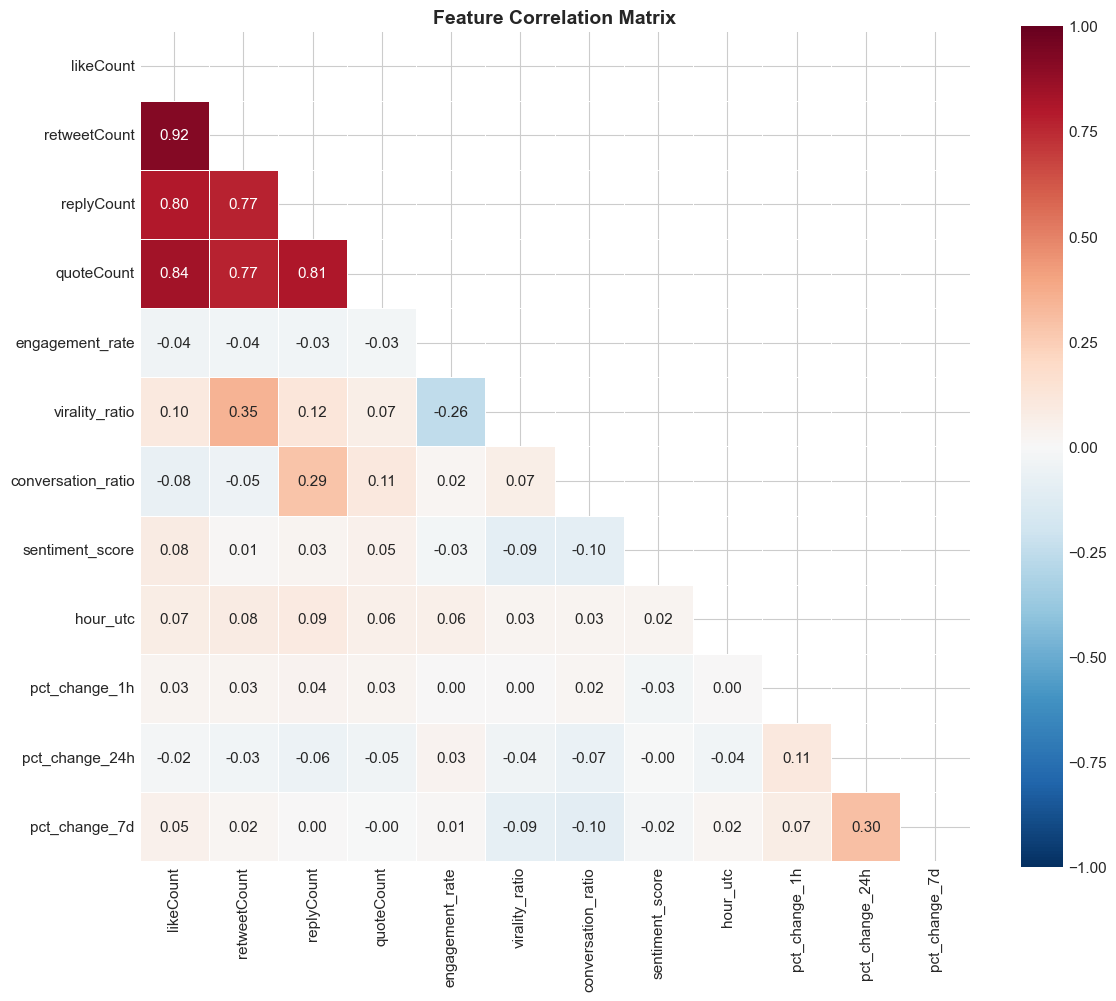


Correlations with Price Changes:
                    pct_change_1h  pct_change_24h  pct_change_7d
likeCount                   0.027          -0.021          0.049
retweetCount                0.026          -0.032          0.016
replyCount                  0.035          -0.061          0.001
quoteCount                  0.028          -0.045         -0.004
engagement_rate             0.001           0.034          0.014
virality_ratio              0.004          -0.040         -0.092
conversation_ratio          0.018          -0.065         -0.104
sentiment_score            -0.027          -0.005         -0.018
hour_utc                    0.002          -0.039          0.023


In [14]:
# Select numerical features for correlation
corr_features = [
    'likeCount', 'retweetCount', 'replyCount', 'quoteCount',
    'engagement_rate', 'virality_ratio', 'conversation_ratio',
    'sentiment_score', 'hour_utc',
    'pct_change_1h', 'pct_change_24h', 'pct_change_7d'
]

corr_matrix = df_clean[corr_features].corr()

# Heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('../reports/figures/10_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Key correlations with price changes
print("\nCorrelations with Price Changes:")
print("="*50)
price_corr = corr_matrix[['pct_change_1h', 'pct_change_24h', 'pct_change_7d']].drop(['pct_change_1h', 'pct_change_24h', 'pct_change_7d'])
print(price_corr.round(3))

---

## 8. Top Impact Tweets

### 8.1 Biggest Price Movers

In [15]:
# Top positive movers (24h)
print("TOP 10 POSITIVE PRICE MOVERS (24h):")
print("="*80)
top_positive = df_clean.nlargest(10, 'pct_change_24h')[['createdAt', 'fullText', 'sentiment', 'event_type', 'price_token', 'pct_change_24h']]
for i, row in top_positive.iterrows():
    print(f"\n{row['createdAt'].strftime('%Y-%m-%d')} | {row['price_token']} | +{row['pct_change_24h']:.1f}%")
    print(f"Sentiment: {row['sentiment']} | Event: {row['event_type']}")
    print(f"Tweet: {row['fullText'][:100]}..." if len(row['fullText']) > 100 else f"Tweet: {row['fullText']}")

TOP 10 POSITIVE PRICE MOVERS (24h):

2021-04-15 | DOGE | +100.2%
Sentiment: positive | Event: meme_joke
Tweet: Doge Barking at the Moon https://t.co/QFB81D7zOL

2021-04-15 | DOGE | +100.2%
Sentiment: positive | Event: meme_joke
Tweet: @WSBChairman Doge Barking at the Moon – Miro https://t.co/1vTM2XOusy

2022-04-03 | DOGE | +16.2%
Sentiment: neutral | Event: none
Tweet: @Erdayastronaut @Tesla Raptor pump power is over 100MW per engine &amp; 33 engines, means over 3GW. ...

2025-03-01 | DOGE | +15.8%
Sentiment: negative | Event: criticism
Tweet: @DOGE Not good uses of taxpayer money

2025-02-28 | DOGE | +15.8%
Sentiment: positive | Event: market_commentary
Tweet: @BasedMikeLee @DOGE This will be interesting indeed

2025-02-28 | DOGE | +15.8%
Sentiment: positive | Event: endorsement
Tweet: @MarshaBlackburn @DOGE Your support and that of the whole DOGE caucus is much appreciated!

2025-02-28 | DOGE | +15.8%
Sentiment: positive | Event: endorsement
Tweet: Cool

2025-02-28 | DOGE | +15.8%
Se

In [16]:
# Top negative movers (24h)
print("TOP 10 NEGATIVE PRICE MOVERS (24h):")
print("="*80)
top_negative = df_clean.nsmallest(10, 'pct_change_24h')[['createdAt', 'fullText', 'sentiment', 'event_type', 'price_token', 'pct_change_24h']]
for i, row in top_negative.iterrows():
    print(f"\n{row['createdAt'].strftime('%Y-%m-%d')} | {row['price_token']} | {row['pct_change_24h']:.1f}%")
    print(f"Sentiment: {row['sentiment']} | Event: {row['event_type']}")
    print(f"Tweet: {row['fullText'][:100]}..." if len(row['fullText']) > 100 else f"Tweet: {row['fullText']}")

TOP 10 NEGATIVE PRICE MOVERS (24h):

2016-04-02 | DOGE | -32.0%
Sentiment: positive | Event: none
Tweet: Token of appreciation for those who lined up coming via mail. Thought maybe 20-30 people per store w...

2021-05-11 | DOGE | -20.6%
Sentiment: positive | Event: payment_adoption
Tweet: Do you want Tesla to accept Doge?

2025-03-02 | DOGE | -16.9%
Sentiment: positive | Event: market_commentary
Tweet: @DOGE is a threat to the bureaucracy 
 https://t.co/nFw18EFBCz

2025-03-02 | DOGE | -16.9%
Sentiment: positive | Event: endorsement
Tweet: @stillgray Just another far left propaganda machine. 

@DOGE has pushed to hire, not fire air traffi...

2025-03-01 | DOGE | -16.9%
Sentiment: positive | Event: endorsement
Tweet: Exactly

2025-03-01 | DOGE | -16.9%
Sentiment: positive | Event: endorsement
Tweet: @nicksortor DOGE has very high approval from the people as a whole, but the grifters super hate it

2025-03-01 | DOGE | -16.9%
Sentiment: positive | Event: partnership
Tweet: @samstein All fe

---

## 9. Statistical Tests

### 9.1 Is the Mean Price Change Significantly Different from Zero?

In [17]:
from scipy import stats

print("One-Sample T-Tests (H0: mean = 0):")
print("="*50)

for col in ['pct_change_1h', 'pct_change_24h', 'pct_change_7d']:
    data = df_clean[col].dropna()
    t_stat, p_value = stats.ttest_1samp(data, 0)
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"\n{col}:")
    print(f"  Mean: {data.mean():.4f}%")
    print(f"  t-statistic: {t_stat:.3f}")
    print(f"  p-value: {p_value:.4f} {significance}")

One-Sample T-Tests (H0: mean = 0):

pct_change_1h:
  Mean: -0.0170%
  t-statistic: -0.743
  p-value: 0.4580 

pct_change_24h:
  Mean: -0.3577%
  t-statistic: -1.685
  p-value: 0.0924 

pct_change_7d:
  Mean: -2.0182%
  t-statistic: -4.205
  p-value: 0.0000 ***


### 9.2 Sentiment Group Comparison

In [18]:
# ANOVA: Do different sentiments lead to different price changes?
print("ANOVA Test: Price Change by Sentiment")
print("="*50)

for col in ['pct_change_1h', 'pct_change_24h', 'pct_change_7d']:
    groups = [df_clean[df_clean['sentiment'] == s][col].dropna() for s in ['positive', 'neutral', 'negative']]
    f_stat, p_value = stats.f_oneway(*groups)
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"\n{col}: F={f_stat:.3f}, p={p_value:.4f} {significance}")

ANOVA Test: Price Change by Sentiment

pct_change_1h: F=0.054, p=0.9472 

pct_change_24h: F=0.394, p=0.6746 

pct_change_7d: F=0.984, p=0.3743 
